# CBIR Evaluation Notebook

This notebook compares CBIR Method 1, CBIR Method 2, and CBIR Method 3 on the same held-out test split.

Workflow:
1. Load the shared split file created by the training notebooks.
2. Build method-specific in-memory galleries from split `gallery` images.
3. Evaluate all methods on split `test` images.
4. Report side-by-side metrics and confusion matrices.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json
import importlib
import sys

import cv2
import numpy as np
from numpy.typing import NDArray
import scipy.spatial.distance as sp_distance
import face_recognition
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks.python import vision as mp_vision
import urllib.request
    

pd = importlib.import_module("pandas")
sns = importlib.import_module("seaborn")

ImageArray = NDArray[np.uint8]
FloatArray = NDArray[np.float32]

project_root: Path = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

FACE_DIR: Path = project_root / "data" / "face"
MODELS_DIR: Path = project_root / "models"
INDEX_DIR: Path = project_root / "index"
EVAL_OUTPUT_DIR: Path = MODELS_DIR / "evaluation"
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_PATH: Path = INDEX_DIR / "cbir_eval_split.json"

METHODS: dict[str, dict[str, Any]] = {
    "cbir_method1": {
        "meta_path": INDEX_DIR / "cbir_method1_meta.json",
        "threshold": 0.50,
        "strict_unknown_threshold": 0.50,
        "min_margin": 0.02,
    },
    "cbir_method2": {
        "meta_path": INDEX_DIR / "cbir_method2_meta.json",
        "threshold": 0.50,
        "strict_unknown_threshold": 0.50,
        "min_margin": 0.02,
    },
    "cbir_method3": {
        "meta_path": INDEX_DIR / "cbir_method3_meta.json",
        "threshold": 0.50,
        "strict_unknown_threshold": 0.50,
        "min_margin": 0.02,
    },
}
UNKNOWN_LABEL = "unknown"
quit = sys.exit
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {project_root}")
print(f"Split path  : {SPLIT_PATH}")
print(f"Eval outputs: {EVAL_OUTPUT_DIR}")

Project root: c:\Users\jaft9\School\AttSystem
Split path  : c:\Users\jaft9\School\AttSystem\index\cbir_eval_split.json
Eval outputs: c:\Users\jaft9\School\AttSystem\models\evaluation


In [ ]:
_FACE_DETECTOR = None

def get_face_detector():
    global _FACE_DETECTOR
    if _FACE_DETECTOR is not None:
        return _FACE_DETECTOR
        

    model_path = project_root / "models" / "blaze_face_short_range.tflite"
    if not model_path.exists():
        model_path.parent.mkdir(parents=True, exist_ok=True)
        print("Downloading BlazeFace model...")
        url = "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
        urllib.request.urlretrieve(url, str(model_path))
        
    options = mp_vision.FaceDetectorOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=str(model_path)),
        min_detection_confidence=0.5
    )
    _FACE_DETECTOR = mp_vision.FaceDetector.create_from_options(options)
    return _FACE_DETECTOR


def detect_face_roi(bgr: ImageArray) -> ImageArray:

    face_detector = get_face_detector()
    
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    results = face_detector.detect(mp_image)
    
    if not results.detections:
        side: int = int(min(h, w) * 0.75)
        cx, cy = w // 2, h // 2
        x1: int = max(0, cx - side // 2)
        y1: int = max(0, cy - side // 2)
        x2: int = min(w, x1 + side)
        y2: int = min(h, y1 + side)
        return rgb[y1:y2, x1:x2].astype(np.uint8, copy=False)
        
    best_detection = max(
        results.detections,
        key=lambda d: d.bounding_box.width * d.bounding_box.height
    )
    bboxC = best_detection.bounding_box
    x = int(bboxC.origin_x)
    y = int(bboxC.origin_y)
    fw = int(bboxC.width)
    fh = int(bboxC.height)
    
    pad_w: int = int(fw * 0.2)
    pad_h: int = int(fh * 0.2)

    x1: int = max(0, x - pad_w)
    y1: int = max(0, y - pad_h)
    x2: int = min(w, x + fw + pad_w)
    y2: int = min(h, y + fh + pad_h)

    return rgb[y1:y2, x1:x2].astype(np.uint8, copy=False)


def preprocess_roi_method1(roi_rgb: ImageArray, output_size: tuple[int, int] = (128, 128)) -> ImageArray:
    resized = cv2.resize(roi_rgb, output_size, interpolation=cv2.INTER_CUBIC)
    return resized.astype(np.uint8, copy=False)


def preprocess_roi_method2(roi_rgb: ImageArray, output_size: tuple[int, int] = (128, 128)) -> ImageArray:
    hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2HSV)
    h_c, s_c, v_c = cv2.split(hsv)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    v_c = clahe.apply(v_c)
    hsv_enhanced = cv2.merge([h_c, s_c, v_c])
    enhanced_roi = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2RGB)
    
    resized = cv2.resize(enhanced_roi, output_size, interpolation=cv2.INTER_CUBIC)
    return resized.astype(np.uint8, copy=False)


def preprocess_roi_method3(roi_gray: ImageArray, output_size: tuple[int, int] = (128, 128)) -> ImageArray:
    equalized = cv2.equalizeHist(roi_gray)
    denoised = cv2.bilateralFilter(equalized, d=7, sigmaColor=50, sigmaSpace=50)
    sharpened = cv2.addWeighted(denoised, 1.35, cv2.GaussianBlur(denoised, (0, 0), 1.2), -0.35, 0)
    resized = cv2.resize(sharpened, output_size, interpolation=cv2.INTER_CUBIC)
    return cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB).astype(np.uint8, copy=False)


def extract_embedding_from_face(face_rgb: ImageArray) -> FloatArray | None:
    h, w = face_rgb.shape[:2]
    known_face_locations = [(0, w, h, 0)]
    encodings: list[Any] = face_recognition.face_encodings(face_rgb, known_face_locations=known_face_locations)
    if len(encodings) == 0:
        return None

    emb = np.array(encodings[0], dtype=np.float32)
    return emb

In [ ]:
def load_split(path: Path) -> dict[str, dict[str, list[str]]]:
    if not path.exists():
        raise FileNotFoundError(
            f"Split file not found at {path}. Run cbir_method1 and cbir_method2 notebooks first."
        )

    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    identities = payload.get("identities", payload)
    split_data: dict[str, dict[str, list[str]]] = {}
    for person, parts in identities.items():
        if not isinstance(parts, dict):
            continue
        split_data[str(person)] = {
            "gallery": [str(x) for x in parts.get("gallery", [])],
            "test": [str(x) for x in parts.get("test", [])],
        }
    return split_data


def load_method_thresholds(meta_path: Path) -> dict[str, float]:
    if not meta_path.exists():
        return {}
    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)
    
    threshold = float(meta.get("similarity_threshold", meta.get("threshold", 0.50)))
    return {
        "threshold": threshold,
        "strict_unknown_threshold": float(meta.get("similarity_strict_unknown_threshold", threshold)),
        "min_margin": float(meta.get("similarity_min_margin", 0.02)),
    }


def collect_person_files(face_dir: Path) -> dict[str, list[Path]]:
    if not face_dir.exists() or not face_dir.is_dir():
        raise FileNotFoundError(f"Missing dataset folder: {face_dir}")

    out: dict[str, list[Path]] = {}
    for person_dir in sorted([p for p in face_dir.iterdir() if p.is_dir()]):
        files = sorted(
            [
                p
                for p in person_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
            ]
        )
        if files:
            out[person_dir.name] = files
    return out


# --- PERFORMANCE OPTIMIZATIONS ---
_ROI_CACHE: dict[str, ImageArray] = {}

def get_cached_roi(path_str: str) -> ImageArray:
    if path_str in _ROI_CACHE:
        return _ROI_CACHE[path_str]
    
    bgr = cv2.imread(path_str, cv2.IMREAD_COLOR)
    if bgr is None:
        roi = np.array([])
    else:
        roi = detect_face_roi(bgr)
        
    _ROI_CACHE[path_str] = roi
    return roi

def load_method_gallery(
    method_name: str,
) -> tuple[FloatArray, NDArray[np.int32], dict[int, str], dict[str, int]]:
    meta_path = METHODS[method_name]["meta_path"]
    index_path = meta_path.with_name(method_name + "_index.npz")
    
    if not index_path.exists() or not meta_path.exists():
        raise FileNotFoundError(f"Missing saved index/meta for {method_name}. Please run its notebook first.")

    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)
        
    label_names = meta.get("label_names", [])
    id_to_name = {i: name for i, name in enumerate(label_names)}
    name_to_id = {name: i for i, name in enumerate(label_names)}
    
    index_data = np.load(index_path)
    emb_np = np.ascontiguousarray(index_data["embeddings"].astype(np.float32))
    label_np = np.asarray(index_data["labels"], dtype=np.int32)
    
    print(f"[{method_name}] Loaded {emb_np.shape[0]} gallery vectors directly from disk!")
    return emb_np, label_np, id_to_name, name_to_id

In [51]:
def predict_identity(
    query_embedding: FloatArray,
    gallery_embeddings: FloatArray,
    gallery_labels: NDArray[np.int32],
    id_to_name: dict[int, str],
    threshold: float,
    strict_unknown_threshold: float,
    min_margin: float,
) -> tuple[str, float, float, bool, str]:
    distances = sp_distance.cdist([query_embedding], gallery_embeddings, metric="euclidean")[0]
    order = np.argsort(distances)
    best_idx = int(order[0])

    best_distance = float(distances[best_idx])
    best_similarity = 1.0 - best_distance
    best_label_id = int(gallery_labels[best_idx])
    raw_pred = id_to_name.get(best_label_id, UNKNOWN_LABEL)

    other_mask = gallery_labels != best_label_id
    if np.any(other_mask):
        second_distance = float(np.min(distances[other_mask]))
    else:
        second_distance = 1.0
    second_similarity = 1.0 - second_distance
    margin = max(0.0, best_similarity - second_similarity)

    accepted = (
        best_similarity >= threshold
        and best_similarity >= strict_unknown_threshold
        and margin >= min_margin
    )
    pred_label = raw_pred if accepted else UNKNOWN_LABEL
    return pred_label, best_similarity, margin, accepted, raw_pred


def evaluate_method(
    method_name: str,
    person_files: dict[str, list[Path]],
    split_data: dict[str, dict[str, list[str]]],
    unknown_people: list[str],
) -> dict[str, Any]:
    thresholds = METHODS[method_name].copy()
    loaded = load_method_thresholds(METHODS[method_name]["meta_path"])
    thresholds.update(loaded)

    threshold = float(thresholds["threshold"])
    strict_unknown_threshold = float(thresholds["strict_unknown_threshold"])
    min_margin = float(thresholds["min_margin"])

    gallery_embeddings, gallery_labels, id_to_name, name_to_id = load_method_gallery(method_name)

    y_true: list[str] = []
    y_pred: list[str] = []
    best_sims: list[float] = []
    margins: list[float] = []
    is_genuine_top1: list[bool] = []
    
    known_total = 0
    known_correct = 0
    unknown_total = 0
    unknown_correct = 0
    evaluated = 0

    try:
        from tqdm.auto import tqdm
    except ImportError:
        class tqdm:
            def __init__(self, total, desc=None): pass
            def update(self, n=1): pass
            def close(self): pass
            def __enter__(self): return self
            def __exit__(self, exc_type, exc_val, exc_tb): pass

    # Compute total samples for the progress bar
    total_test_files = sum(
        1 for person_name in person_files.keys()
        for p in person_files[person_name] 
        if p.name in set(split_data.get(person_name, {}).get("test", []))
    )

    with tqdm(total=total_test_files, desc=f"Evaluating {method_name}") as pbar:
        for person_name in sorted(person_files.keys()):
            test_names = set(split_data.get(person_name, {}).get("test", []))
            test_files = [p for p in person_files[person_name] if p.name in test_names]
            if not test_files:
                continue

            is_unknown_identity = person_name in unknown_people
            for path in test_files:
                roi = get_cached_roi(str(path))
                if roi.size == 0:
                    pbar.update(1)
                    continue

                if method_name == "cbir_method3":
                    roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
                    sample = preprocess_roi_method3(roi_gray, output_size=(128, 128))
                elif method_name == "cbir_method2":
                    sample = preprocess_roi_method2(roi, output_size=(128, 128))
                else:
                    sample = preprocess_roi_method1(roi, output_size=(128, 128))

                if sample.size == 0:
                    pbar.update(1)
                    continue

                emb = extract_embedding_from_face(sample)
                if emb is None:
                    pbar.update(1)
                    continue

                if is_unknown_identity:
                    true_label = UNKNOWN_LABEL
                else:
                    true_label = person_name if person_name in name_to_id else UNKNOWN_LABEL

                pred_label, best_similarity, margin, accepted, raw_pred = predict_identity(
                    emb,
                    gallery_embeddings,
                    gallery_labels,
                    id_to_name,
                    threshold=threshold,
                    strict_unknown_threshold=strict_unknown_threshold,
                    min_margin=min_margin,
                )

                y_true.append(true_label)
                y_pred.append(pred_label)
                best_sims.append(best_similarity)
                margins.append(margin)
                
                # Check if the closest gallery match is actually the correct person
                is_genuine = (true_label == raw_pred) and (true_label != UNKNOWN_LABEL)
                is_genuine_top1.append(is_genuine)
                
                evaluated += 1

                if true_label == UNKNOWN_LABEL:
                    unknown_total += 1
                    if pred_label == UNKNOWN_LABEL:
                        unknown_correct += 1
                else:
                    known_total += 1
                    if pred_label == true_label:
                        known_correct += 1
                
                pbar.update(1)

    if evaluated == 0:
        raise RuntimeError(f"No evaluable test samples for {method_name}. Check split file and images.")

    overall_acc = sum(1 for t, p in zip(y_true, y_pred) if t == p) / evaluated
    known_acc = (known_correct / known_total) if known_total else float("nan")
    unknown_reject = (unknown_correct / unknown_total) if unknown_total else float("nan")

    return {
        "method": method_name,
        "threshold": threshold,
        "strict_unknown_threshold": strict_unknown_threshold,
        "min_margin": min_margin,
        "num_gallery_vectors": int(gallery_embeddings.shape[0]),
        "num_eval_samples": evaluated,
        "known_samples": known_total,
        "unknown_samples": unknown_total,
        "overall_accuracy": overall_acc,
        "known_accuracy": known_acc,
        "unknown_reject_rate": unknown_reject,
        "y_true": y_true,
        "y_pred": y_pred,
        "best_sims": best_sims,
        "margins": margins,
        "is_genuine_top1": is_genuine_top1,
        "labels": sorted(set(y_true) | set(y_pred)),
    }

In [52]:
def build_confusion_matrix(
    y_true: list[str],
    y_pred: list[str],
    labels: list[str],
) -> NDArray[np.int32]:
    idx = {label: i for i, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm


def print_confusion_matrix(cm: NDArray[np.int32], labels: list[str], title: str) -> None:
    print()
    print(title)
    header = "true\\pred".ljust(16) + " ".join(label[:12].ljust(12) for label in labels)
    print(header)
    for i, label in enumerate(labels):
        row = label[:12].ljust(16) + " ".join(str(int(v)).ljust(12) for v in cm[i])
        print(row)


split_data = load_split(SPLIT_PATH)
person_files = collect_person_files(FACE_DIR)

# Unknown identities are those with no gallery images and at least one test image.
unknown_people = [
    person
    for person, parts in split_data.items()
    if len(parts.get("gallery", [])) == 0 and len(parts.get("test", [])) > 0
]

print(f"Total identities in split: {len(split_data)}")
print(f"Unknown-only identities: {len(unknown_people)}")

Total identities in split: 21
Unknown-only identities: 0


In [53]:
results = []
for method_name in ["cbir_method1", "cbir_method2", "cbir_method3"]:
    print()
    print(f"Evaluating {method_name} ...")
    metrics = evaluate_method(
        method_name=method_name,
        person_files=person_files,
        split_data=split_data,
        unknown_people=unknown_people,
    )
    results.append(metrics)

for m in results:
    print()
    print(f"Method: {m['method']}")
    print(f"  Gallery vectors       : {m['num_gallery_vectors']}")
    print(f"  Evaluated samples     : {m['num_eval_samples']}")
    print(f"  Known samples         : {m['known_samples']}")
    print(f"  Unknown samples       : {m['unknown_samples']}")
    print(f"  Overall accuracy      : {m['overall_accuracy']:.4f}")
    print(f"  Known accuracy        : {m['known_accuracy']:.4f}" if not np.isnan(m['known_accuracy']) else "  Known accuracy        : n/a")
    print(f"  Unknown reject rate   : {m['unknown_reject_rate']:.4f}" if not np.isnan(m['unknown_reject_rate']) else "  Unknown reject rate   : n/a")
    print(f"  Threshold             : {m['threshold']:.4f}")
    print(f"  Strict unknown thr    : {m['strict_unknown_threshold']:.4f}")
    print(f"  Min margin            : {m['min_margin']:.4f}")

best = max(results, key=lambda x: x["overall_accuracy"])
print()
print(f"Best overall accuracy: {best['method']} ({best['overall_accuracy']:.4f})")


Evaluating cbir_method1 ...
[cbir_method1] Loaded 3498 gallery vectors directly from disk!


Evaluating cbir_method1:   0%|          | 0/874 [00:00<?, ?it/s]


Evaluating cbir_method2 ...
[cbir_method2] Loaded 3498 gallery vectors directly from disk!


Evaluating cbir_method2:   0%|          | 0/874 [00:00<?, ?it/s]


Evaluating cbir_method3 ...
[cbir_method3] Loaded 3498 gallery vectors directly from disk!


Evaluating cbir_method3:   0%|          | 0/874 [00:00<?, ?it/s]


Method: cbir_method1
  Gallery vectors       : 3498
  Evaluated samples     : 874
  Known samples         : 874
  Unknown samples       : 0
  Overall accuracy      : 0.9783
  Known accuracy        : 0.9783
  Unknown reject rate   : n/a
  Threshold             : 0.5000
  Strict unknown thr    : 0.5000
  Min margin            : 0.0200

Method: cbir_method2
  Gallery vectors       : 3498
  Evaluated samples     : 874
  Known samples         : 874
  Unknown samples       : 0
  Overall accuracy      : 0.9817
  Known accuracy        : 0.9817
  Unknown reject rate   : n/a
  Threshold             : 0.5000
  Strict unknown thr    : 0.5000
  Min margin            : 0.0200

Method: cbir_method3
  Gallery vectors       : 3498
  Evaluated samples     : 874
  Known samples         : 874
  Unknown samples       : 0
  Overall accuracy      : 0.9748
  Known accuracy        : 0.9748
  Unknown reject rate   : n/a
  Threshold             : 0.5000
  Strict unknown thr    : 0.5000
  Min margin            :

In [54]:
summary_rows: list[dict[str, Any]] = []
for item in results:
    summary_rows.append(
        {
            "method": item["method"],
            "gallery_vectors": item["num_gallery_vectors"],
            "eval_samples": item["num_eval_samples"],
            "known_samples": item["known_samples"],
            "unknown_samples": item["unknown_samples"],
            "overall_accuracy": item["overall_accuracy"],
            "known_accuracy": item["known_accuracy"],
            "unknown_reject_rate": item["unknown_reject_rate"],
            "threshold": item["threshold"],
            "strict_unknown_threshold": item["strict_unknown_threshold"],
            "min_margin": item["min_margin"],
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("overall_accuracy", ascending=False).reset_index(drop=True)
summary_df_rounded = summary_df.copy()
for col in ["overall_accuracy", "known_accuracy", "unknown_reject_rate", "threshold", "strict_unknown_threshold", "min_margin"]:
    summary_df_rounded[col] = summary_df_rounded[col].astype(float).round(4)

display(summary_df_rounded)

summary_csv_path = EVAL_OUTPUT_DIR / "method_comparison_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)
print(f"Saved summary table: {summary_csv_path}")

,method,gallery_vectors,eval_samples,known_samples,unknown_samples,overall_accuracy,known_accuracy,unknown_reject_rate,threshold,strict_unknown_threshold,min_margin
0,cbir_method2,3498,874,874,0,0.9817,0.9817,NaN,0.5,0.5,0.02
1,cbir_method1,3498,874,874,0,0.9783,0.9783,NaN,0.5,0.5,0.02
2,cbir_method3,3498,874,874,0,0.9748,0.9748,NaN,0.5,0.5,0.02


Saved summary table: c:\Users\jaft9\School\AttSystem\models\evaluation\method_comparison_summary.csv


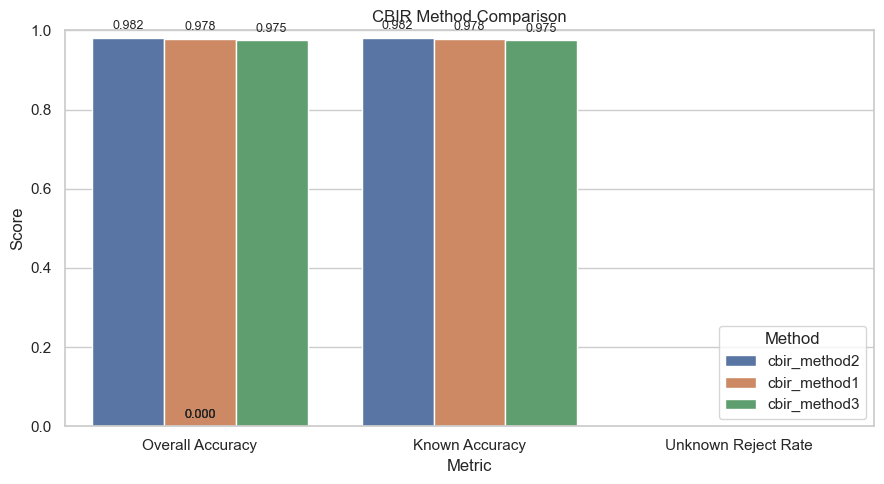

Saved chart: c:\Users\jaft9\School\AttSystem\models\evaluation\metric_comparison_bar.png


In [55]:
metrics_for_chart = ["overall_accuracy", "known_accuracy", "unknown_reject_rate"]
chart_df = summary_df[["method"] + metrics_for_chart].melt(
    id_vars=["method"],
    value_vars=metrics_for_chart,
    var_name="metric",
    value_name="value",
)

metric_name_map = {
    "overall_accuracy": "Overall Accuracy",
    "known_accuracy": "Known Accuracy",
    "unknown_reject_rate": "Unknown Reject Rate",
}
chart_df["metric"] = chart_df["metric"].map(metric_name_map)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=chart_df, x="metric", y="value", hue="method")
ax.set_title("CBIR Method Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.0)
ax.legend(title="Method", loc="lower right")

for patch in ax.patches:
    patch_any: Any = patch
    height = float(patch_any.get_height())
    if np.isfinite(height):
        ax.annotate(
            f"{height:.3f}",
            (float(patch_any.get_x()) + float(patch_any.get_width()) / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 4),
            textcoords="offset points",
        )

plt.tight_layout()
metric_chart_path = EVAL_OUTPUT_DIR / "metric_comparison_bar.png"
plt.savefig(metric_chart_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved chart: {metric_chart_path}")

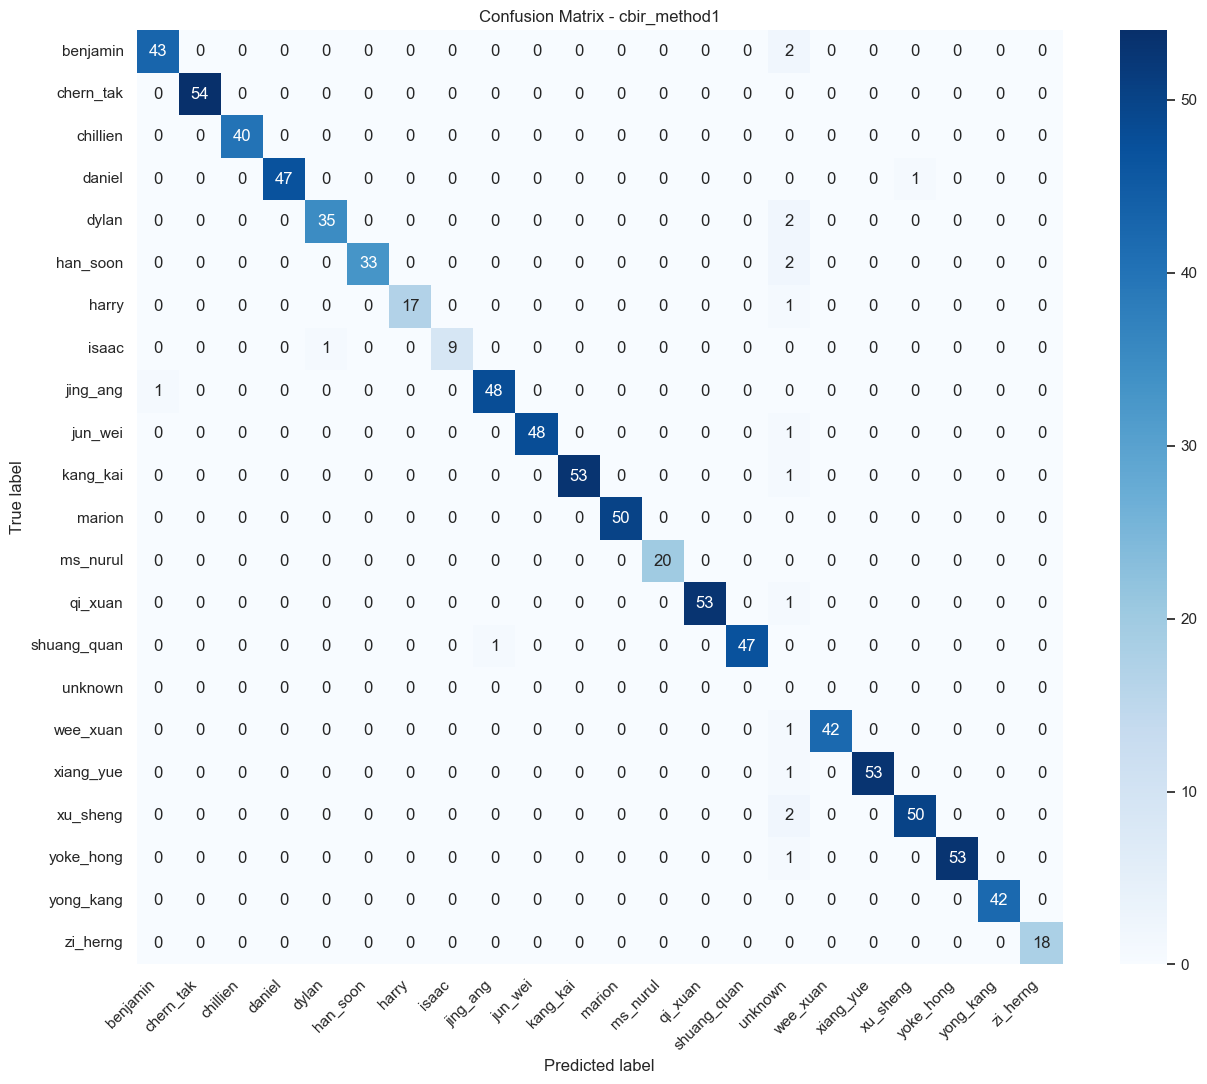

Saved confusion matrix: c:\Users\jaft9\School\AttSystem\models\evaluation\confusion_matrix_cbir_method1.png


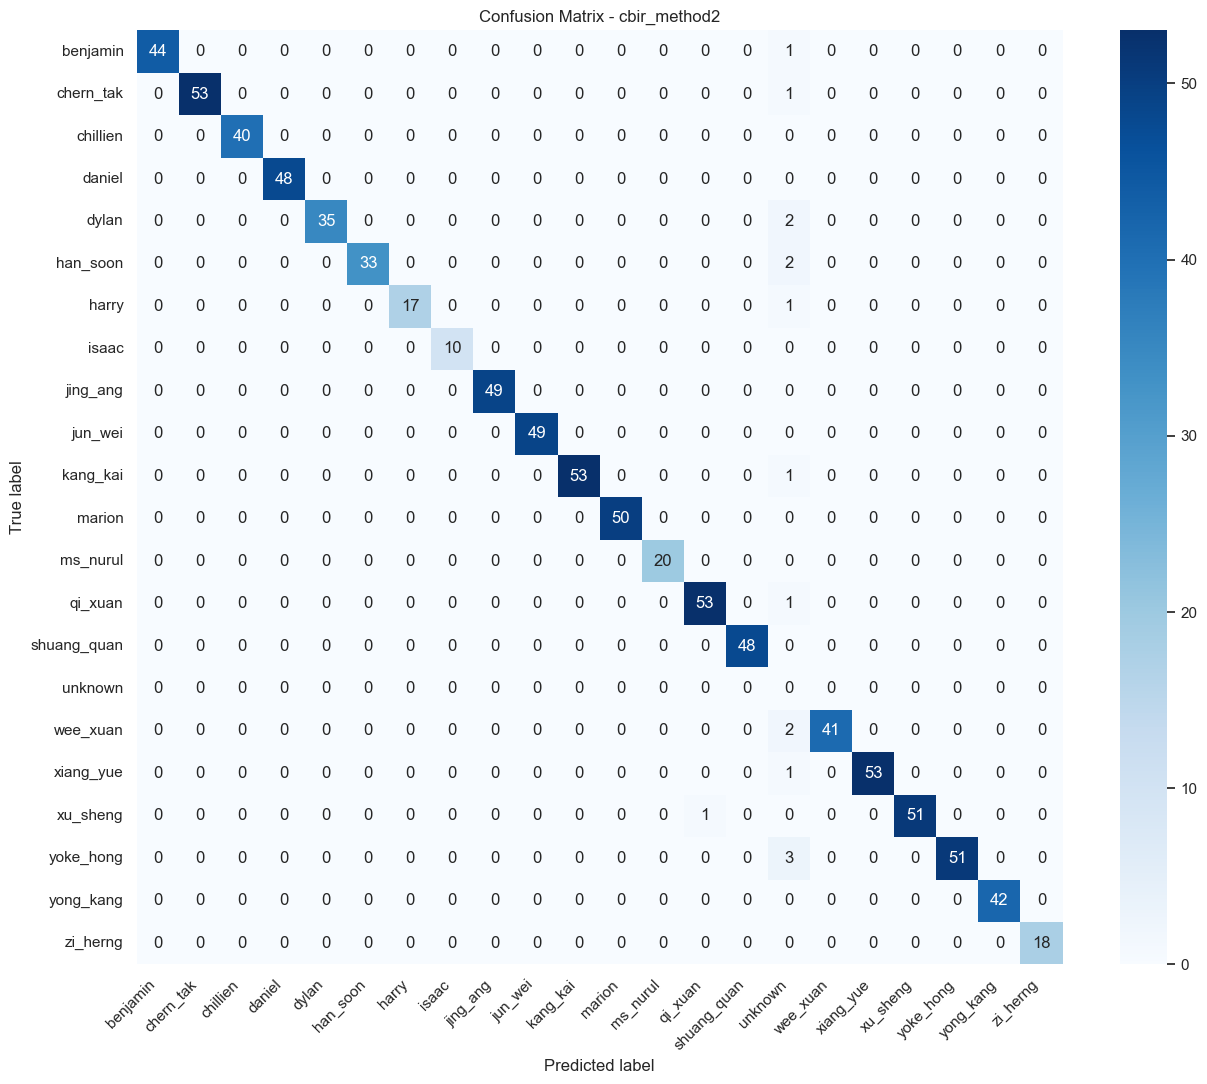

Saved confusion matrix: c:\Users\jaft9\School\AttSystem\models\evaluation\confusion_matrix_cbir_method2.png


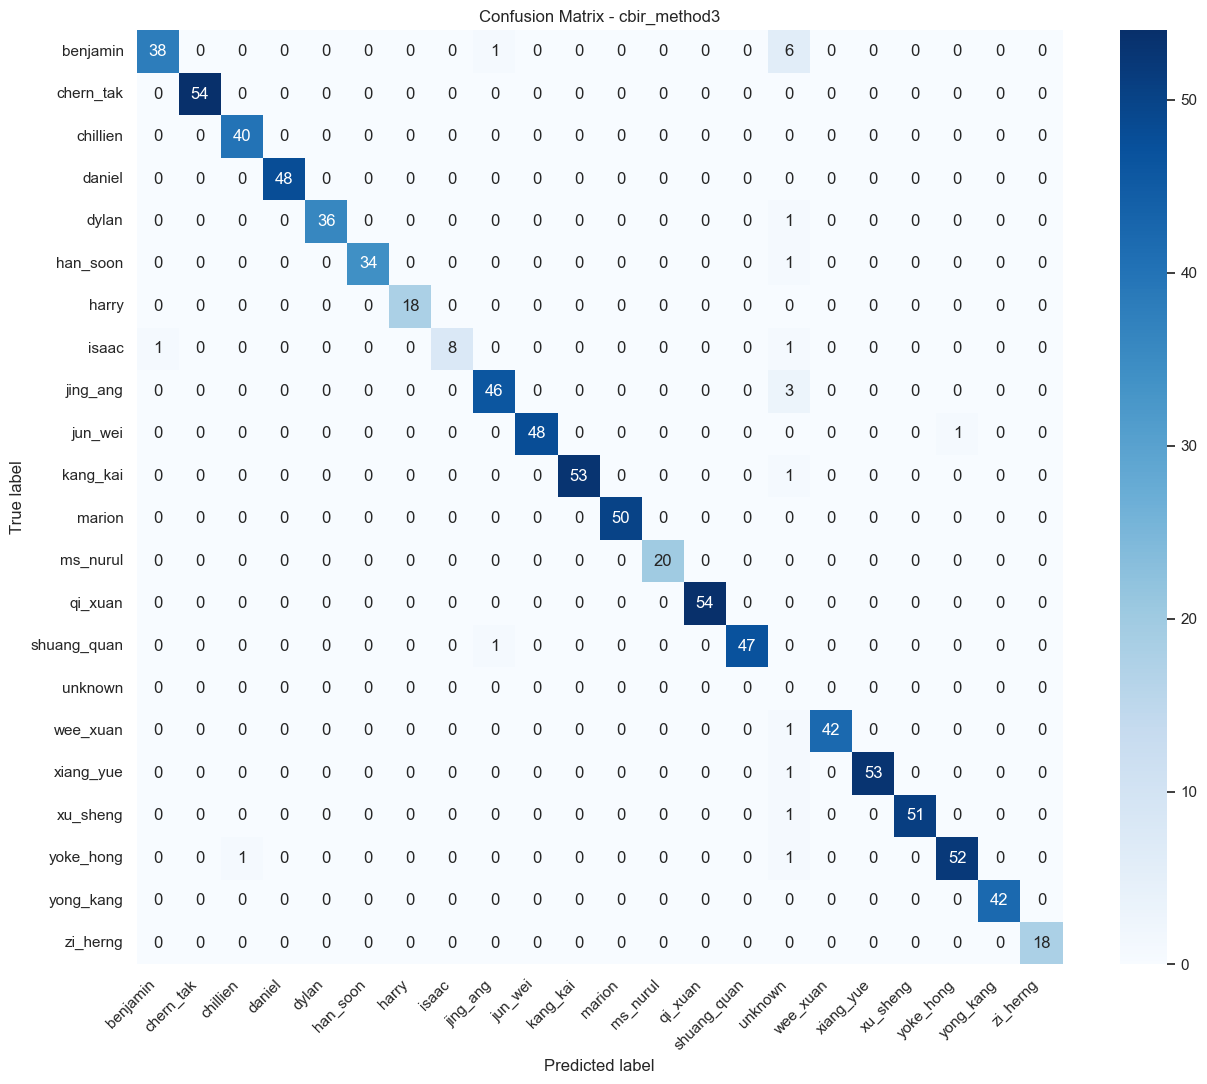

Saved confusion matrix: c:\Users\jaft9\School\AttSystem\models\evaluation\confusion_matrix_cbir_method3.png


In [56]:
for item in results:
    labels = item["labels"]
    cm = build_confusion_matrix(item["y_true"], item["y_pred"], labels)

    fig, ax = plt.subplots(figsize=(max(7, len(labels) * 0.6), max(5, len(labels) * 0.5)))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix - {item['method']}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    cm_path = EVAL_OUTPUT_DIR / f"confusion_matrix_{item['method']}.png"
    plt.savefig(cm_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix: {cm_path}")

C:\Users\jaft9\AppData\Local\Temp\ipykernel_28836\397013622.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")


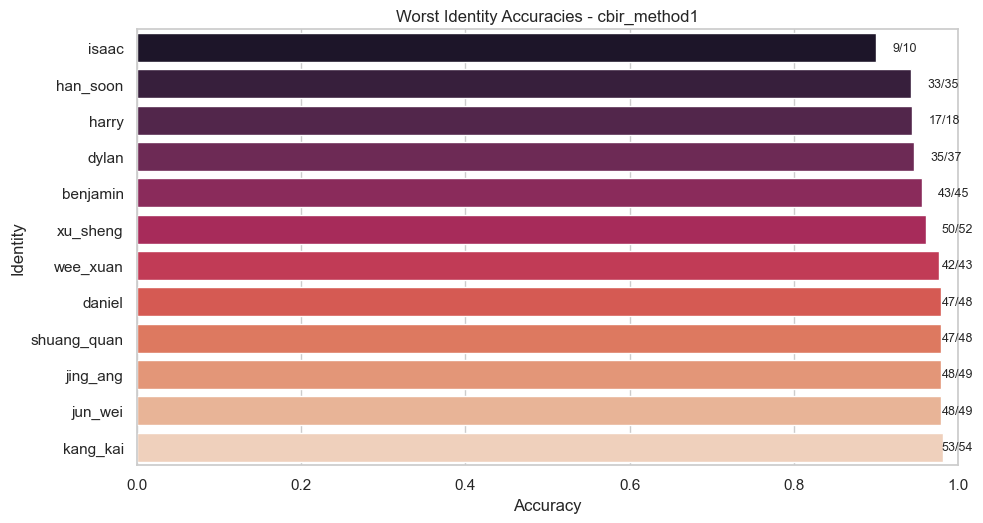

Saved per-identity chart: c:\Users\jaft9\School\AttSystem\models\evaluation\worst_identities_cbir_method1.png
Saved per-identity table: c:\Users\jaft9\School\AttSystem\models\evaluation\per_identity_accuracy_cbir_method1.csv


C:\Users\jaft9\AppData\Local\Temp\ipykernel_28836\397013622.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")


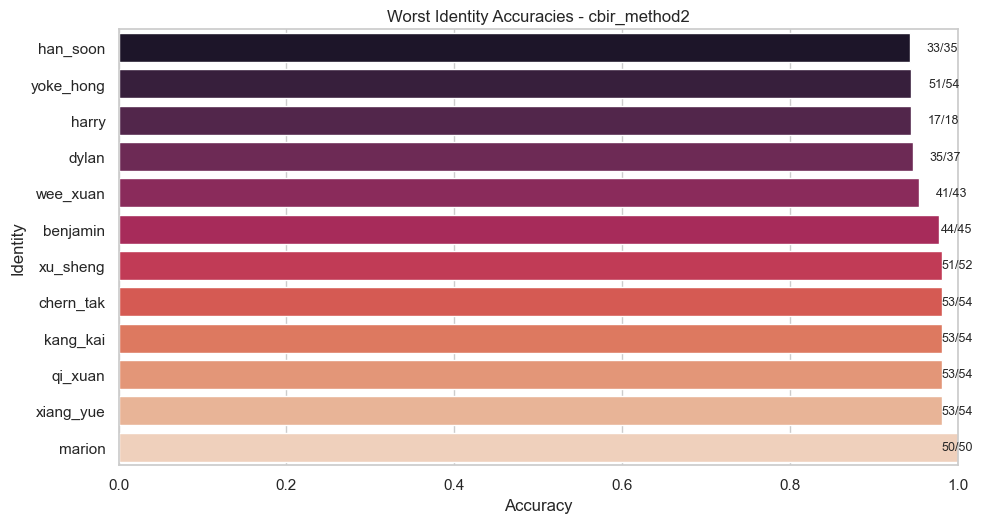

Saved per-identity chart: c:\Users\jaft9\School\AttSystem\models\evaluation\worst_identities_cbir_method2.png
Saved per-identity table: c:\Users\jaft9\School\AttSystem\models\evaluation\per_identity_accuracy_cbir_method2.csv


C:\Users\jaft9\AppData\Local\Temp\ipykernel_28836\397013622.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")


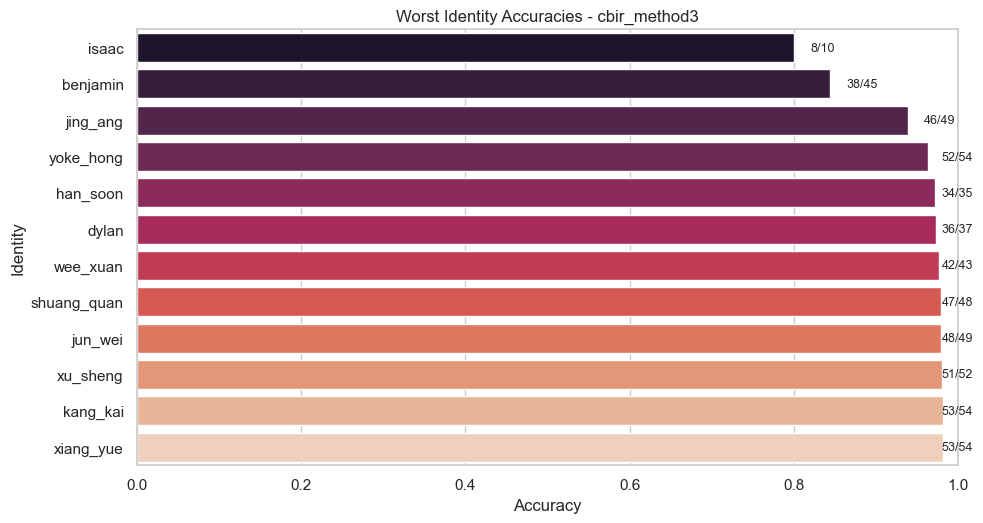

Saved per-identity chart: c:\Users\jaft9\School\AttSystem\models\evaluation\worst_identities_cbir_method3.png
Saved per-identity table: c:\Users\jaft9\School\AttSystem\models\evaluation\per_identity_accuracy_cbir_method3.csv


In [57]:
def per_identity_accuracy(y_true: list[str], y_pred: list[str]):
    counters: dict[str, dict[str, int]] = {}
    for t, p in zip(y_true, y_pred):
        if t == UNKNOWN_LABEL:
            continue
        if t not in counters:
            counters[t] = {"total": 0, "correct": 0}
        counters[t]["total"] += 1
        if t == p:
            counters[t]["correct"] += 1

    rows = []
    for person, info in counters.items():
        total = info["total"]
        correct = info["correct"]
        acc = (correct / total) if total else float("nan")
        rows.append({"identity": person, "samples": total, "correct": correct, "accuracy": acc})

    return pd.DataFrame(rows).sort_values(["accuracy", "samples"], ascending=[True, False])


for item in results:
    pid_df = per_identity_accuracy(item["y_true"], item["y_pred"])
    if pid_df.empty:
        print(f"No per-identity rows for {item['method']}.")
        continue

    top_n = min(12, len(pid_df))
    worst_df = pid_df.head(top_n).sort_values("accuracy", ascending=True)

    plt.figure(figsize=(10, max(4, top_n * 0.45)))
    ax = sns.barplot(data=worst_df, x="accuracy", y="identity", orient="h", palette="rocket")
    ax.set_title(f"Worst Identity Accuracies - {item['method']}")
    ax.set_xlim(0.0, 1.0)
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Identity")
    for i, (_, row) in enumerate(worst_df.iterrows()):
        ax.text(
            min(0.98, float(row['accuracy']) + 0.02),
            i,
            f"{int(row['correct'])}/{int(row['samples'])}",
            va="center",
            fontsize=9,
        )
    plt.tight_layout()

    out_path = EVAL_OUTPUT_DIR / f"worst_identities_{item['method']}.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved per-identity chart: {out_path}")

    pid_csv = EVAL_OUTPUT_DIR / f"per_identity_accuracy_{item['method']}.csv"
    pid_df.to_csv(pid_csv, index=False)
    print(f"Saved per-identity table: {pid_csv}")

In [58]:
def top_confusions(y_true: list[str], y_pred: list[str], top_k: int = 15):
    confusion_counts: dict[tuple[str, str], int] = {}
    for t, p in zip(y_true, y_pred):
        if t == p:
            continue
        key = (t, p)
        confusion_counts[key] = confusion_counts.get(key, 0) + 1

    if not confusion_counts:
        return pd.DataFrame(columns=["true_label", "predicted_label", "count"])

    rows = [
        {"true_label": t, "predicted_label": p, "count": c}
        for (t, p), c in confusion_counts.items()
    ]
    df = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    return df.head(top_k)


error_rows = []
for item in results:
    df = top_confusions(item["y_true"], item["y_pred"], top_k=20)
    if df.empty:
        print(f"No misclassifications found for {item['method']}.")
        continue
    df.insert(0, "method", item["method"])
    error_rows.append(df)
    print()
    print(f"Top confusions for {item['method']}")
    display(df)

if error_rows:
    combined_errors = pd.concat(error_rows, ignore_index=True)
    errors_csv = EVAL_OUTPUT_DIR / "top_confusions.csv"
    combined_errors.to_csv(errors_csv, index=False)
    print(f"Saved error table: {errors_csv}")


Top confusions for cbir_method1


,method,true_label,predicted_label,count
0,cbir_method1,benjamin,unknown,2
1,cbir_method1,dylan,unknown,2
2,cbir_method1,han_soon,unknown,2
3,cbir_method1,xu_sheng,unknown,2
4,cbir_method1,daniel,xu_sheng,1
5,cbir_method1,harry,unknown,1
6,cbir_method1,isaac,dylan,1
7,cbir_method1,jing_ang,benjamin,1
8,cbir_method1,jun_wei,unknown,1
9,cbir_method1,kang_kai,unknown,1



Top confusions for cbir_method2


,method,true_label,predicted_label,count
0,cbir_method2,yoke_hong,unknown,3
1,cbir_method2,dylan,unknown,2
2,cbir_method2,han_soon,unknown,2
3,cbir_method2,wee_xuan,unknown,2
4,cbir_method2,benjamin,unknown,1
5,cbir_method2,chern_tak,unknown,1
6,cbir_method2,harry,unknown,1
7,cbir_method2,kang_kai,unknown,1
8,cbir_method2,qi_xuan,unknown,1
9,cbir_method2,xiang_yue,unknown,1



Top confusions for cbir_method3


,method,true_label,predicted_label,count
0,cbir_method3,benjamin,unknown,6
1,cbir_method3,jing_ang,unknown,3
2,cbir_method3,benjamin,jing_ang,1
3,cbir_method3,dylan,unknown,1
4,cbir_method3,han_soon,unknown,1
5,cbir_method3,isaac,unknown,1
6,cbir_method3,isaac,benjamin,1
7,cbir_method3,jun_wei,yoke_hong,1
8,cbir_method3,kang_kai,unknown,1
9,cbir_method3,shuang_quan,jing_ang,1


Saved error table: c:\Users\jaft9\School\AttSystem\models\evaluation\top_confusions.csv


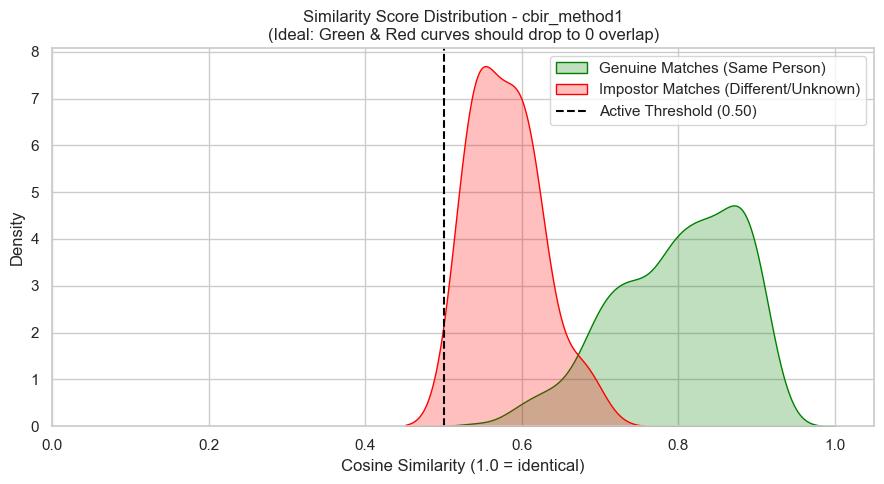

Saved distribution plot: c:\Users\jaft9\School\AttSystem\models\evaluation\sim_distribution_cbir_method1.png


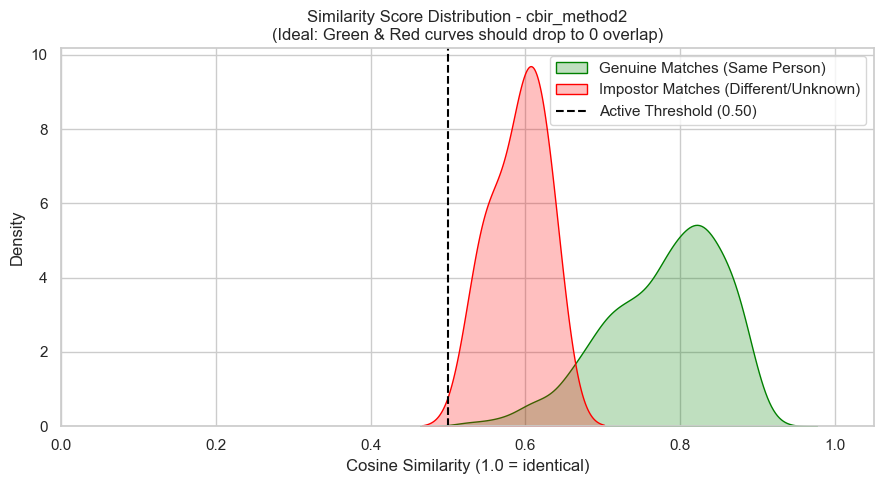

Saved distribution plot: c:\Users\jaft9\School\AttSystem\models\evaluation\sim_distribution_cbir_method2.png


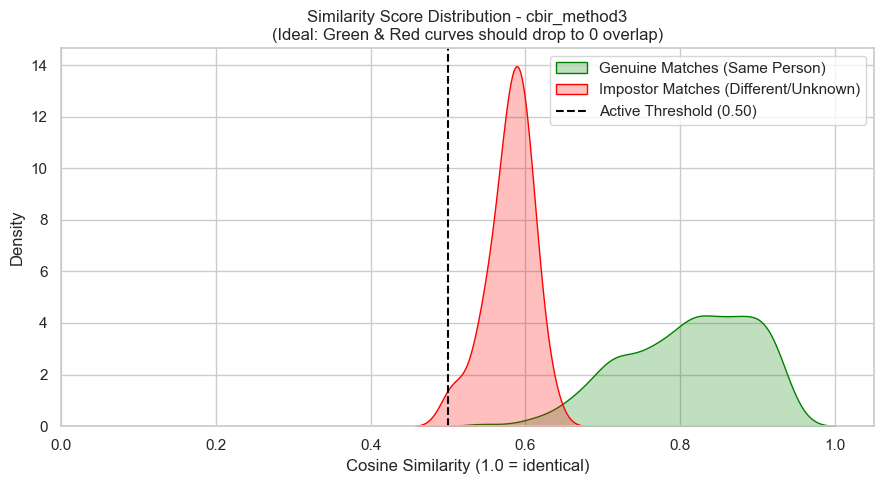

Saved distribution plot: c:\Users\jaft9\School\AttSystem\models\evaluation\sim_distribution_cbir_method3.png


In [ ]:
# --- DIAGNOSTIC EVALUATION METHODS ---
# Model Issue Diagnosis: Distance Distributions & Margin Histograms

def plot_similarity_distributions(results_list: list[dict[str, Any]]):
    """
    Plots the Genuine vs. Impostor similarity score distributions.
    This reveals if your feature embeddings are actually separating classes properly.
    """
    for item in results_list:
        method = item["method"]
        sims = np.array(item["best_sims"])
        genuine_mask = np.array(item["is_genuine_top1"])
        
        y_true = np.array(item["y_true"])
        # Impostor: either an 'unknown' person matching to someone, 
        # or a 'known' person whose top match was wrong.
        impostor_mask = ~genuine_mask
        
        plt.figure(figsize=(9, 5))
        
        if np.any(genuine_mask):
            sns.kdeplot(sims[genuine_mask], fill=True, label="Genuine Matches (Same Person)", color="green", clip=(0.0, 1.0))
            
        if np.any(impostor_mask):
            sns.kdeplot(sims[impostor_mask], fill=True, label="Impostor Matches (Different/Unknown)", color="red", clip=(0.0, 1.0))
            
        # Draw threshold bounds
        plt.axvline(item["threshold"], color="black", linestyle="--", label=f"Active Threshold ({item['threshold']:.2f})")
        
        plt.title(f"Similarity Score Distribution - {method}\n(Ideal: Green & Red curves should drop to 0 overlap)")
        plt.xlabel("Similarity Score (1.0 = identical, based on 1.0 - Euclidean)")
        plt.ylabel("Density")
        plt.xlim(0.0, 1.05)
        plt.legend()
        plt.tight_layout()
        
        dist_path = EVAL_OUTPUT_DIR / f"sim_distribution_{method}.png"
        plt.savefig(dist_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved distribution plot: {dist_path}")

plot_similarity_distributions(results)

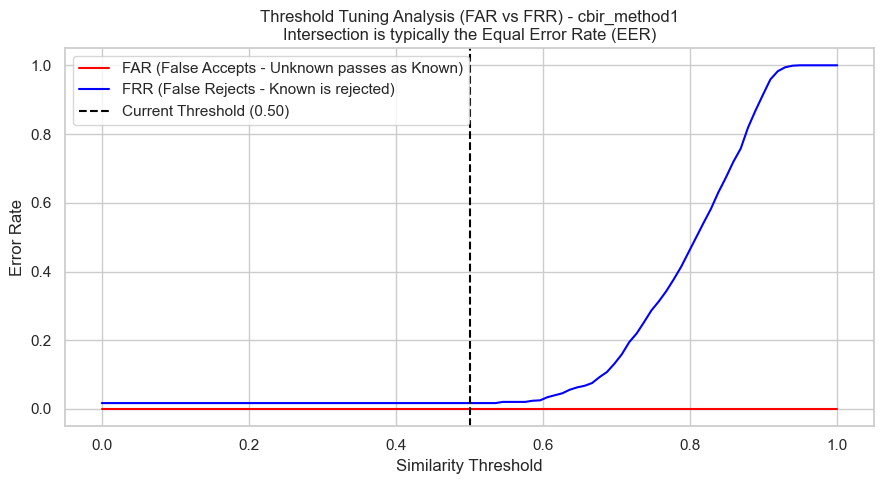

Saved Threshold Tuning trace: c:\Users\jaft9\School\AttSystem\models\evaluation\far_frr_curve_cbir_method1.png


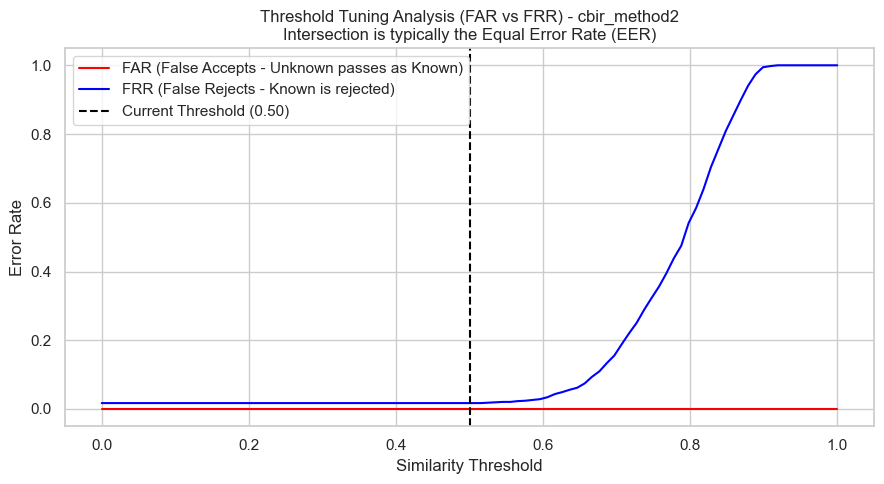

Saved Threshold Tuning trace: c:\Users\jaft9\School\AttSystem\models\evaluation\far_frr_curve_cbir_method2.png


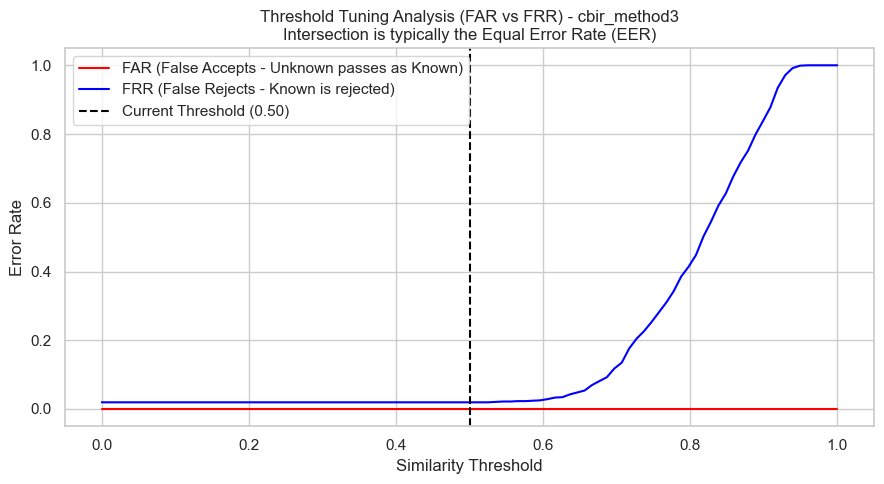

Saved Threshold Tuning trace: c:\Users\jaft9\School\AttSystem\models\evaluation\far_frr_curve_cbir_method3.png


In [60]:
def generate_far_frr_plot(results_list: list[dict[str, Any]]):
    """
    Plots FAR (False Acceptance Rate) vs FRR (False Rejection Rate) tuning curves.
    Evaluates what happens if you dynamically shift your threshold.
    """
    thresholds_to_test = np.linspace(0.0, 1.0, 100)
    
    for item in results_list:
        method = item["method"]
        sims = np.array(item["best_sims"])
        margins = np.array(item["margins"])
        
        # True answers
        y_true = np.array(item["y_true"])
        is_known = y_true != UNKNOWN_LABEL
        is_unknown = np.logical_not(is_known)
        
        # Baseline margins from config
        min_margin = item["min_margin"]
        
        far_rates = []
        frr_rates = []
        
        for thr in thresholds_to_test:
            # Predict accepted
            pred_accepted = (sims >= thr) & (margins >= min_margin)
            
            # FRR: known sample, but we rejected it (or it's the wrong person, but we didn't filter it correctly; technically FRR is when a known user is rejected)
            if np.sum(is_known) > 0:
                frr: float = np.sum(is_known & ~pred_accepted) / np.sum(is_known)
            else:
                frr = 0.0
                
            # FAR: unknown sample, but we passed it
            if np.sum(is_unknown) > 0:
                far: float = np.sum(is_unknown & pred_accepted) / np.sum(is_unknown)
            else:
                far = 0.0
                
            far_rates.append(far)
            frr_rates.append(frr)
            
        plt.figure(figsize=(9, 5))
        plt.plot(thresholds_to_test, far_rates, label="FAR (False Accepts - Unknown passes as Known)", color="red")
        plt.plot(thresholds_to_test, frr_rates, label="FRR (False Rejects - Known is rejected)", color="blue")
        
        # Current active threshold line
        current_thr = item["threshold"]
        plt.axvline(current_thr, color="black", linestyle="--", label=f"Current Threshold ({current_thr:.2f})")
        
        plt.title(f"Threshold Tuning Analysis (FAR vs FRR) - {method}\nIntersection is typically the Equal Error Rate (EER)")
        plt.xlabel("Similarity Threshold")
        plt.ylabel("Error Rate")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        
        far_frr_path = EVAL_OUTPUT_DIR / f"far_frr_curve_{method}.png"
        plt.savefig(far_frr_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved Threshold Tuning trace: {far_frr_path}")

generate_far_frr_plot(results)